<a href="https://colab.research.google.com/github/skyish21/AIML-Python/blob/main/DL/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [68]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid


import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
#%matplotlib inline

In [69]:
# Convert MNIST Image files into a tensor of 3-Dimensions (Channels × Height × Width)

transform = transforms.ToTensor() # images to tensor

We separate them because:

- Training data is used to teach the model

- Test data is used to evaluate how well the model learned (on unseen data)

In [70]:
# Train Data
train_data = datasets.MNIST(root="/mnist_data", train=True, download=True, transform=transform)

In [71]:
# Test Data
test_data = datasets.MNIST(root="/mnist_data", train=False, download=True, transform=transform)

In [72]:
train_data

Dataset MNIST
    Number of datapoints: 60000
    Root location: /mnist_data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [73]:
test_data

Dataset MNIST
    Number of datapoints: 10000
    Root location: /mnist_data
    Split: Test
    StandardTransform
Transform: ToTensor()

In [74]:
# create a small batch size for images
train_loader = DataLoader(train_data, batch_size=10, shuffle=True)
test_loader = DataLoader(test_data, batch_size=10, shuffle=False)

In [75]:
# define our CNN model
# describe convolutional layer and what it's doing ( 2 convolutional layer)

# 1 input = 1 image, 6 output = 6 feature maps, 3x3 kernel size, 1 stride
convo1 = nn.Conv2d(1, 6, 3, 1)
convo2 = nn.Conv2d(6, 16, 3, 1)

This loop iterates through the training data just once (break stops it after first iteration)

It extracts one data point consisting of:

- X_train: The image data (features)

- y_train: The label (target number 0-9)

In [76]:
# get one record from MNIST data
for i, (X_train, y_train) in enumerate(train_data):
    break

In [77]:
X_train.shape # 1 image of size 28 x 28, 1-D image

torch.Size([1, 28, 28])

In [78]:
# change image to 4-D batch
# 1 image in batch, 1 grayscale image, 28 x 28 size
x = X_train.view(1,1,28,28)

In [79]:
# Perform 1st convolution
x = F.relu(convo1(x)) # rectified linear unit for our activation function

In [80]:
x.shape # 1 image, 6 filters/feature maps, 26 x 26 image after filter

torch.Size([1, 6, 26, 26])

In [81]:
# pass through the pooling layer
# 2x2 kernel size, stride of 2
x = F.max_pool2d(x, 2, 2)

In [82]:
x.shape # 1 image, 5 filters/feature maps, 13 x 13 image size

torch.Size([1, 6, 13, 13])

In [83]:
# do our second convolutional layer
x = F.relu(convo2(x))

In [84]:
x.shape # 1 image, 16 filters/feature maps, 11 x 11 image after filter

torch.Size([1, 16, 11, 11])

In [85]:
# pass through the pooling layer 2
# 2x2 kernel size, stride of 2
x = F.max_pool2d(x, 2, 2)

In [86]:
# 11/2 = 5.5 but we have to round down, because we can't invent data to round up
x.shape # 1 image, 5 filters/feature maps, 5 x 5 image size

torch.Size([1, 16, 5, 5])

In [87]:
# model class
class MNIST_CNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.convo1 = nn.Conv2d(1, 6, 3, 1)
    self.convo2 = nn.Conv2d(6, 16, 3, 1)

    # fully connected layer
    self.fc1 = nn.Linear(5*5*16, 120) # 5*5*16 is the x shape previously and 120 is flattening the neurons
    self.fc2 = nn.Linear(120, 84)     # 120 to 84 neurons in 2nd layer
    self.fc3 = nn.Linear(84, 10)      # 84 neurons to 10 output/classes

  # in a NN you need something pushing forward the data
  def forward(self, x):
      x = F.relu(self.convo1(x))
      x = F.max_pool2d(x, 2,2)   # 2x2 is max pool size, 2 stride

      # second pass
      x = F.relu(self.convo2(x))
      x = F.max_pool2d(x, 2,2)

      # third pass
      # reshaping when passing from CNN to fully connected layer
      # Re-view to flatten it out
      # Automatically calculates this dimension based on the tensor's total element count
      # Example: If original tensor has 400 elements, -1 becomes 400/(16*5*5) = 1
      x = x.view(-1, 16*5*5)     # -1 so we can vary the batch size

      # fully connected layers
      x = F.relu(self.fc1(x))
      x = F.relu(self.fc2(x))
      x = self.fc3(x)

      return F.log_softmax(x, dim=1)

In [88]:
# create an instance of our model
# Ensures weight initializations are identical across runs.
torch.manual_seed(21)
model = MNIST_CNN()
model

MNIST_CNN(
  (convo1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1))
  (convo2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [89]:
# loss function optimzer
criterion = nn.CrossEntropyLoss()

# model.parameters(): Passes all trainable weights/biases to the optimizer.
# smaller the learning rate, longer its gonna take, better the training
optimzer = torch.optim.Adam(model.parameters(), lr = 0.001)

In [90]:
import time
start_time = time.time()

# create variables to track things
epochs = 5
train_losses = []
test_losses = []
correct = []
test_correct = []

# train our CNN model
for i in range(epochs):
  trn_corr = 0 # training correct
  tst_corr = 0 # testin correct

  # train
  for j, (X_train, y_train) in enumerate(train_loader):
    j += 1 # start batches at 1, track batch numbers
    y_pred = model(X_train) # get predicted values from training set
    loss = criterion(y_pred, y_train) # compare predicted to true values

    predicted = torch.max(y_pred.data, 1)[1] # get the index of the highest value, add the number of correct predictions
    batch_corr = (predicted == y_train).sum() # how many correct from this batch
    trn_corr += batch_corr

    # backpropogation
    optimzer.zero_grad() # clear gradient
    loss.backward()      # backpropogation
    optimzer.step()      # update weights

    # batch size = 10 => total batches = 60000/10 = 6000
    # every 600 batches print the values
    if j%600 == 0:
      print(f"Epoch: {i}, Batch: {j}, loss: {loss.item()}")

  train_losses.append(loss)
  correct.append(trn_corr)

  # test
  with torch.no_grad(): # no gradient so we don't have to updare our weights and biases with test data
    for j, (X_test, y_test) in enumerate(test_loader):
      y_val = model(X_test) # get the predicted value of unseen test data
      predicted = torch.max(y_val.data, 1)[1] # get the index of highest value, add the number of correct predicitions
      batch_corr2 = (predicted == y_test).sum()
      tst_corr += batch_corr2

  loss = criterion(y_val, y_test)
  test_losses.append(loss)
  correct.append(tst_corr)



current_time = time.time()
elapsed_time = current_time - start_time
print(f"Training took {elapsed_time/60} minutes")

Epoch: 0, Batch: 600, loss: 0.09319356828927994
Epoch: 0, Batch: 1200, loss: 0.2788531184196472
Epoch: 0, Batch: 1800, loss: 0.08645269274711609
Epoch: 0, Batch: 2400, loss: 0.03434322029352188
Epoch: 0, Batch: 3000, loss: 0.005090352613478899
Epoch: 0, Batch: 3600, loss: 0.036832310259342194
Epoch: 0, Batch: 4200, loss: 0.03197989612817764
Epoch: 0, Batch: 4800, loss: 0.005995939020067453
Epoch: 0, Batch: 5400, loss: 0.013253872282803059
Epoch: 0, Batch: 6000, loss: 0.0194401852786541
Epoch: 1, Batch: 600, loss: 0.035812608897686005
Epoch: 1, Batch: 1200, loss: 0.02163688652217388
Epoch: 1, Batch: 1800, loss: 0.00026790497940964997
Epoch: 1, Batch: 2400, loss: 0.09841462224721909
Epoch: 1, Batch: 3000, loss: 0.0016260342672467232
Epoch: 1, Batch: 3600, loss: 0.0025664023123681545
Epoch: 1, Batch: 4200, loss: 0.0034758546389639378
Epoch: 1, Batch: 4800, loss: 0.005476302932947874
Epoch: 1, Batch: 5400, loss: 0.019652506336569786
Epoch: 1, Batch: 6000, loss: 0.15720276534557343
Epoch: 2

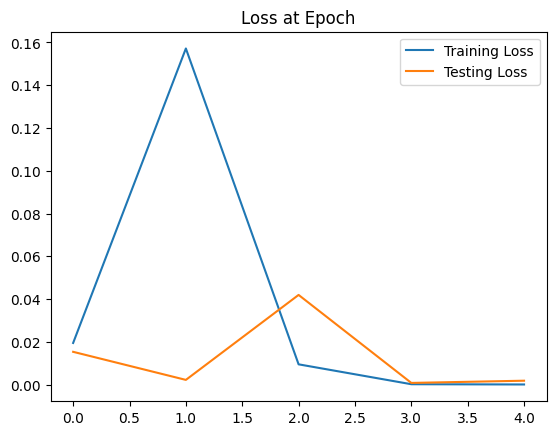

In [91]:
train_losses = [tl.item() for tl in train_losses]
test_losses = [tl.item() for tl in test_losses]


# Graph the loss at eavh epoch
plt.plot(train_losses, label="Training Loss")
plt.plot(test_losses, label="Testing Loss")
plt.title("Loss at Epoch")
plt.legend()

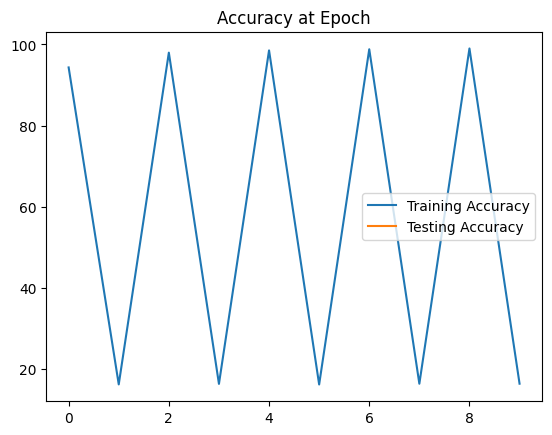

In [92]:
# graph the accuracy at each epoch
plt.plot([t/600 for t in correct], label="Training Accuracy")
plt.plot([t/100 for t in test_correct], label="Testing Accuracy")
plt.title("Accuracy at Epoch")
plt.legend()

In [93]:
test_load_everything = DataLoader(test_data, batch_size=10000, shuffle= False)

In [94]:
with torch.no_grad():
  correct = 0
  for X_test, y_test in test_load_everything:
    y_val = model(X_test)
    predicted = torch.max(y_val.data, 1)[1]
    correct += (predicted == y_test).sum()

print(f"Test Accuracy: {correct/10000}")

Test Accuracy: 0.987500011920929


In [95]:
# Test on the following data
test_data[4215] # Tensor with an image in it, label at the end

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

In [96]:
# Get the data without the label
test_data[4215][0]

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

In [97]:
# Reshape
test_data[4215][0].reshape(28,28)

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000

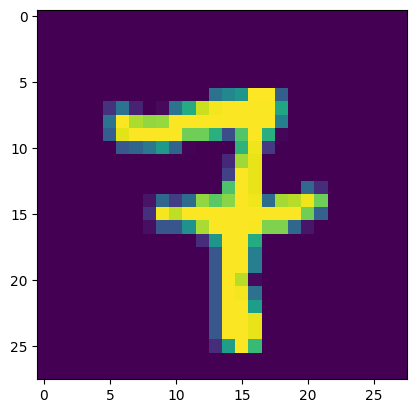

In [98]:
# Show the image
plt.imshow(test_data[4215][0].reshape(28,28))

In [99]:
# Pass the image through the model
model.eval()
with torch.no_grad():
  new_prediction = model(test_data[4215][0].view(1,1,28,28)) # batch size of 1,1 colour channel, 28x28 image

In [100]:
# Check the new prediction (in probabilities)
new_prediction

tensor([[-3.0271e+01, -1.1460e+01, -1.1781e+01, -1.2816e+01, -1.3235e+01,
         -2.3837e+01, -2.3322e+01, -2.4914e-05, -1.9131e+01, -1.3004e+01]])

In [102]:
new_prediction.argmax() # get the highest probability

tensor(7)